# 03 — Reliability & Calibration Analysis

## Objective
Analyze how confidence aligns with correctness across models.

This notebook evaluates:

- Accuracy
- Overconfidence rate
- Expected Calibration Error (ECE)
- Threshold filtering behavior
- Numeric failure patterns
- Question-type sensitivity

In [1]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
import sys

sys.path.append("../")

from src.metrics import compute_accuracy, compute_overconfidence
from src.calibration import compute_ece
from src.threshold import threshold_analysis

In [2]:
with open("../outputs/results/distilbert_results.pkl", "rb") as f:
    distilbert_results = pickle.load(f)

with open("../outputs/results/roberta_results.pkl", "rb") as f:
    roberta_results = pickle.load(f)

print("Loaded results successfully.")

Loaded results successfully.


# 1️⃣ Accuracy vs Calibration

Accuracy measures correctness.
Calibration measures probability alignment.

Key question:
Does higher accuracy imply better confidence reliability?

# 2️⃣ Overconfidence Analysis

Definition:
High-confidence wrong predictions (score > 0.75 and incorrect).

Why it matters:
Overconfidence is operationally dangerous in deployed systems.

Metric:
Overconfidence rate = fraction of confident wrong predictions.

# 3️⃣ Expected Calibration Error (ECE)

ECE measures the average gap between:
- Predicted confidence
- Actual accuracy

Lower ECE → better probability alignment.

Important:
ECE does not measure correctness.
It measures honesty of confidence.

In [3]:
print("DistilBERT Accuracy:", compute_accuracy(distilbert_results))
print("RoBERTa Accuracy:", compute_accuracy(roberta_results))

print("DistilBERT Overconfidence:", compute_overconfidence(distilbert_results))
print("RoBERTa Overconfidence:", compute_overconfidence(roberta_results))

print("DistilBERT ECE:", compute_ece(distilbert_results))
print("RoBERTa ECE:", compute_ece(roberta_results))

DistilBERT Accuracy: 0.7
RoBERTa Accuracy: 0.928
DistilBERT Overconfidence: 0.112
RoBERTa Overconfidence: 0.016
DistilBERT ECE: 0.11032681637429231
RoBERTa ECE: 0.23070816746635503


# 4️⃣ Calibration Curves

Plot:
Predicted confidence vs actual accuracy.

Interpretation:
- Above diagonal → underconfident
- Below diagonal → overconfident
- On diagonal → perfectly calibrated

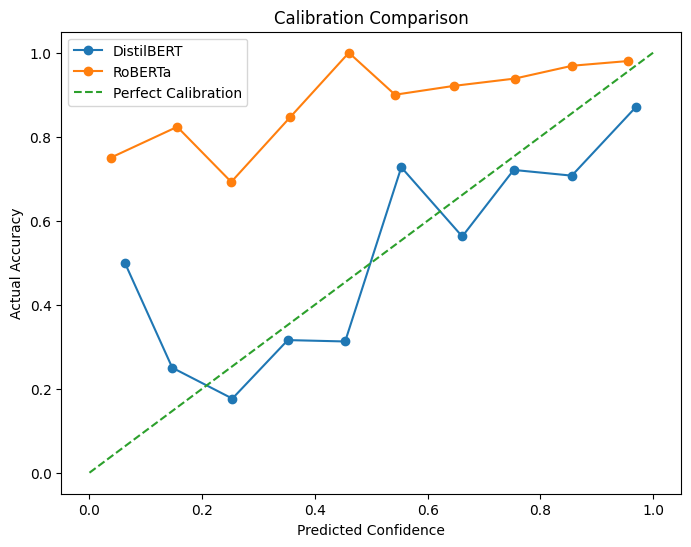

In [4]:
from sklearn.calibration import calibration_curve

def plot_calibration(results):
    scores = np.array([r["score"] for r in results])
    correctness = np.array([1 if r["is_correct"] else 0 for r in results])

    # Clamp scores safely into [0, 1]
    scores = np.clip(scores, 0.0, 1.0)

    prob_true, prob_pred = calibration_curve(
        correctness,
        scores,
        n_bins=10
    )

    return prob_pred, prob_true

distil_pred, distil_true = plot_calibration(distilbert_results)
roberta_pred, roberta_true = plot_calibration(roberta_results)

plt.figure(figsize=(8,6))
plt.plot(distil_pred, distil_true, marker="o", label="DistilBERT")
plt.plot(roberta_pred, roberta_true, marker="o", label="RoBERTa")
plt.plot([0,1], [0,1], linestyle="--", label="Perfect Calibration")

plt.xlabel("Predicted Confidence")
plt.ylabel("Actual Accuracy")
plt.title("Calibration Comparison")
plt.legend()

plt.savefig("../outputs/plots/calibration_comparison.png",
            dpi=300, bbox_inches="tight")

plt.show()

In [5]:
thresholds = np.linspace(0, 1, 20)

distil_acc, distil_cov = threshold_analysis(distilbert_results, thresholds)
roberta_acc, roberta_cov = threshold_analysis(roberta_results, thresholds)

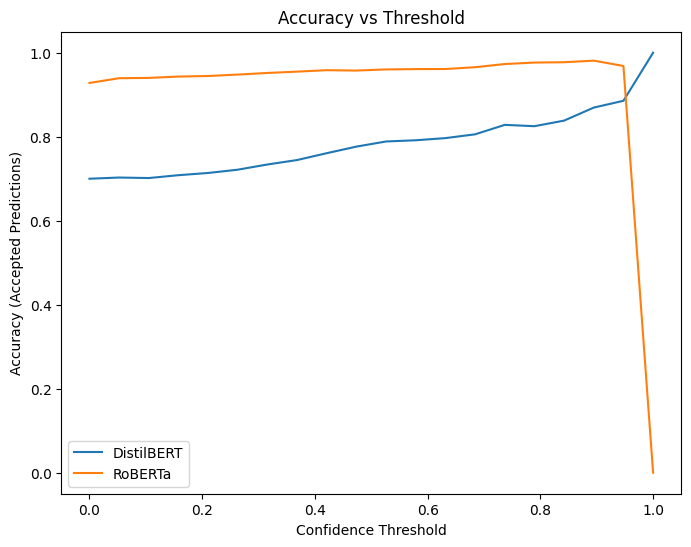

In [6]:
plt.figure(figsize=(8,6))
plt.plot(thresholds, distil_acc, label="DistilBERT")
plt.plot(thresholds, roberta_acc, label="RoBERTa")

plt.xlabel("Confidence Threshold")
plt.ylabel("Accuracy (Accepted Predictions)")
plt.title("Accuracy vs Threshold")
plt.legend()

plt.savefig("../outputs/plots/accuracy_vs_threshold.png",
            dpi=300, bbox_inches="tight")

plt.show()

# 5️⃣ Threshold Filtering

Simulates deployment:

Accept predictions only if:
confidence ≥ threshold

We evaluate:
- Accuracy vs threshold
- Coverage vs threshold

Insight:
Confidence can act as a reliability filter.

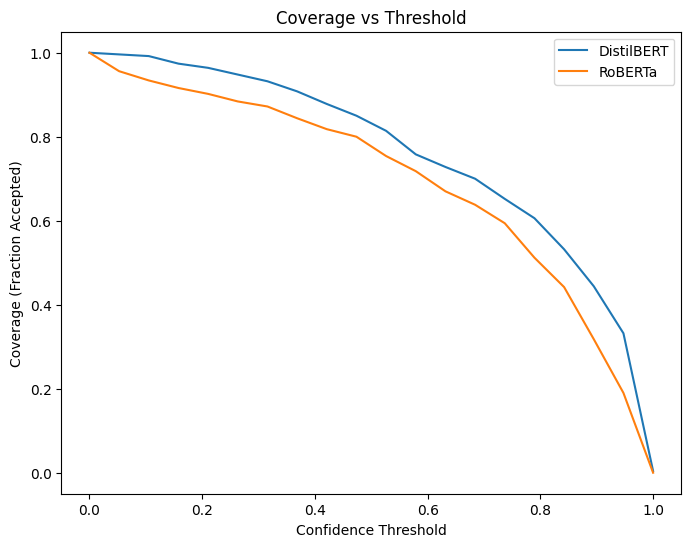

In [7]:
plt.figure(figsize=(8,6))
plt.plot(thresholds, distil_cov, label="DistilBERT")
plt.plot(thresholds, roberta_cov, label="RoBERTa")

plt.xlabel("Confidence Threshold")
plt.ylabel("Coverage (Fraction Accepted)")
plt.title("Coverage vs Threshold")
plt.legend()

plt.savefig("../outputs/plots/coverage_vs_threshold.png",
            dpi=300, bbox_inches="tight")

plt.show()

# 6️⃣ Numeric Failure Analysis

Investigates:
Are numeric errors reasoning failures or span-selection competition?

Findings:
- Numeric failures are rare
- Occur in multi-number contexts
- Primarily selection competition errors

Not arithmetic failure.

In [8]:
def has_digit(text):
    return any(c.isdigit() for c in text)

high_conf_wrong = [
    r for r in roberta_results
    if (not r["is_correct"]) and r["score"] > 0.75
]

numeric_failures = [
    r for r in high_conf_wrong
    if has_digit(r["question"]) or
       has_digit(r["prediction"]) or
       has_digit(r["ground_truth"])
]

print("High-confidence errors:", len(high_conf_wrong))
print("Numeric failures:", len(numeric_failures))

High-confidence errors: 8
Numeric failures: 7


# 7️⃣ Question-Type Sensitivity

Questions grouped into:
- how_many
- who
- when
- where
- what
- other

Observation:
Calibration varies by question type.
Miscalibration is selective, not global.

In [9]:
def question_type(q):
    q = q.lower()
    if q.startswith("how many"):
        return "how_many"
    elif q.startswith("who"):
        return "who"
    elif q.startswith("when"):
        return "when"
    elif q.startswith("where"):
        return "where"
    elif q.startswith("what"):
        return "what"
    else:
        return "other"

type_conf = defaultdict(list)
type_acc = defaultdict(list)

for r in roberta_results:
    qtype = question_type(r["question"])
    type_conf[qtype].append(r["score"])
    type_acc[qtype].append(1 if r["is_correct"] else 0)

for t in type_conf:
    print(
        t,
        "Avg Confidence:", np.mean(type_conf[t]),
        "Accuracy:", np.mean(type_acc[t])
    )


other Avg Confidence: 0.6805035044432609 Accuracy: 0.9719626168224299
where Avg Confidence: 0.5653180070221424 Accuracy: 0.9333333333333333
what Avg Confidence: 0.6610159030026647 Accuracy: 0.9235294117647059
who Avg Confidence: 0.7223122919076099 Accuracy: 0.9191919191919192
how_many Avg Confidence: 0.7762097884878153 Accuracy: 0.8658536585365854
when Avg Confidence: 0.734127708176082 Accuracy: 1.0


## Summary

RoBERTa:
- High accuracy
- Slight global underconfidence
- Strong threshold filtering behavior
- Structured numeric selection failures

DistilBERT:
- Lower accuracy
- Higher overconfidence
- Less reliable under threshold filtering

Confidence behavior is analyzable and structured.